In [7]:
## import dataset

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Load the cleaned dataset

df = pd.read_csv(r'C:\Users\ameen\Lung Cancer Risk Prediction\Lung_Cancer_Cleaned.csv')

## OVERVIEW

In [11]:
# Basic information and summary statistics
print(df.info())
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AGE                     5000 non-null   int64  
 1   GENDER                  5000 non-null   int64  
 2   SMOKING                 5000 non-null   int64  
 3   FINGER_DISCOLORATION    5000 non-null   int64  
 4   MENTAL_STRESS           5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION   5000 non-null   int64  
 6   LONG_TERM_ILLNESS       5000 non-null   int64  
 7   ENERGY_LEVEL            5000 non-null   float64
 8   IMMUNE_WEAKNESS         5000 non-null   int64  
 9   BREATHING_ISSUE         5000 non-null   int64  
 10  ALCOHOL_CONSUMPTION     5000 non-null   int64  
 11  THROAT_DISCOMFORT       5000 non-null   int64  
 12  OXYGEN_SATURATION       5000 non-null   float64
 13  CHEST_TIGHTNESS         5000 non-null   int64  
 14  FAMILY_HISTORY          5000 non-null   

In [13]:
# Age Range
youngest = df['AGE'].min()
oldest = df['AGE'].max()

print(f"Youngest age: {youngest}")
print(f"Oldest age: {oldest}")

Youngest age: 30
Oldest age: 84


In [15]:
# Gender Distribution

print(df['GENDER'].value_counts())


GENDER
1    2506
0    2494
Name: count, dtype: int64


In [17]:
# Categorical Columns

categorical_columns = [
    "GENDER",
    "SMOKING",
    "FINGER_DISCOLORATION",
    "MENTAL_STRESS",
    "EXPOSURE_TO_POLLUTION",
    "LONG_TERM_ILLNESS",
    "PULMONARY_DISEASE",
    "STRESS_IMMUNE",
    "SMOKING_FAMILY_HISTORY",
    "FAMILY_HISTORY",
    "CHEST_TIGHTNESS",
    "THROAT_DISCOMFORT",
    "ALCOHOL_CONSUMPTION",
    "BREATHING_ISSUE"
]

for col in categorical_columns:
    print(f"\nDistribution for {col}:")
    print(df[col].value_counts())


Distribution for GENDER:
GENDER
1    2506
0    2494
Name: count, dtype: int64

Distribution for SMOKING:
SMOKING
1    3332
0    1668
Name: count, dtype: int64

Distribution for FINGER_DISCOLORATION:
FINGER_DISCOLORATION
1    3006
0    1994
Name: count, dtype: int64

Distribution for MENTAL_STRESS:
MENTAL_STRESS
1    2699
0    2301
Name: count, dtype: int64

Distribution for EXPOSURE_TO_POLLUTION:
EXPOSURE_TO_POLLUTION
1    2580
0    2420
Name: count, dtype: int64

Distribution for LONG_TERM_ILLNESS:
LONG_TERM_ILLNESS
0    2804
1    2196
Name: count, dtype: int64

Distribution for PULMONARY_DISEASE:
PULMONARY_DISEASE
NO     2963
YES    2037
Name: count, dtype: int64

Distribution for STRESS_IMMUNE:
STRESS_IMMUNE
0    3952
1    1048
Name: count, dtype: int64

Distribution for SMOKING_FAMILY_HISTORY:
SMOKING_FAMILY_HISTORY
0    3980
1    1020
Name: count, dtype: int64

Distribution for FAMILY_HISTORY:
FAMILY_HISTORY
0    3491
1    1509
Name: count, dtype: int64

Distribution for CHEST_TI

## VISUALIZATION

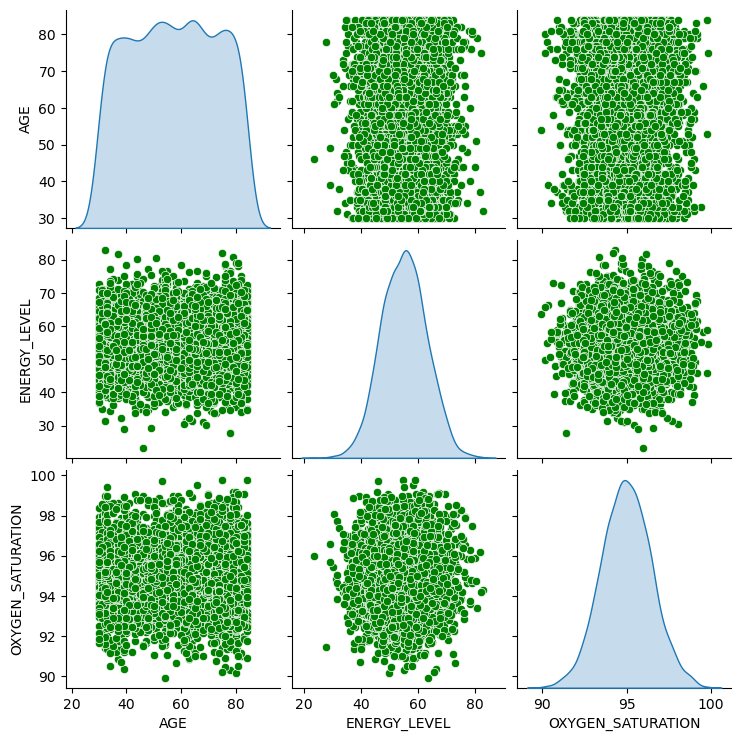

In [17]:
# CONTINUOUS VARIABLES

# Pair Plot For Age, Energy Level and Oxygen Saturation

sns.pairplot(df[['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']], diag_kind='kde', plot_kws={'color': 'green'})
plt.show()

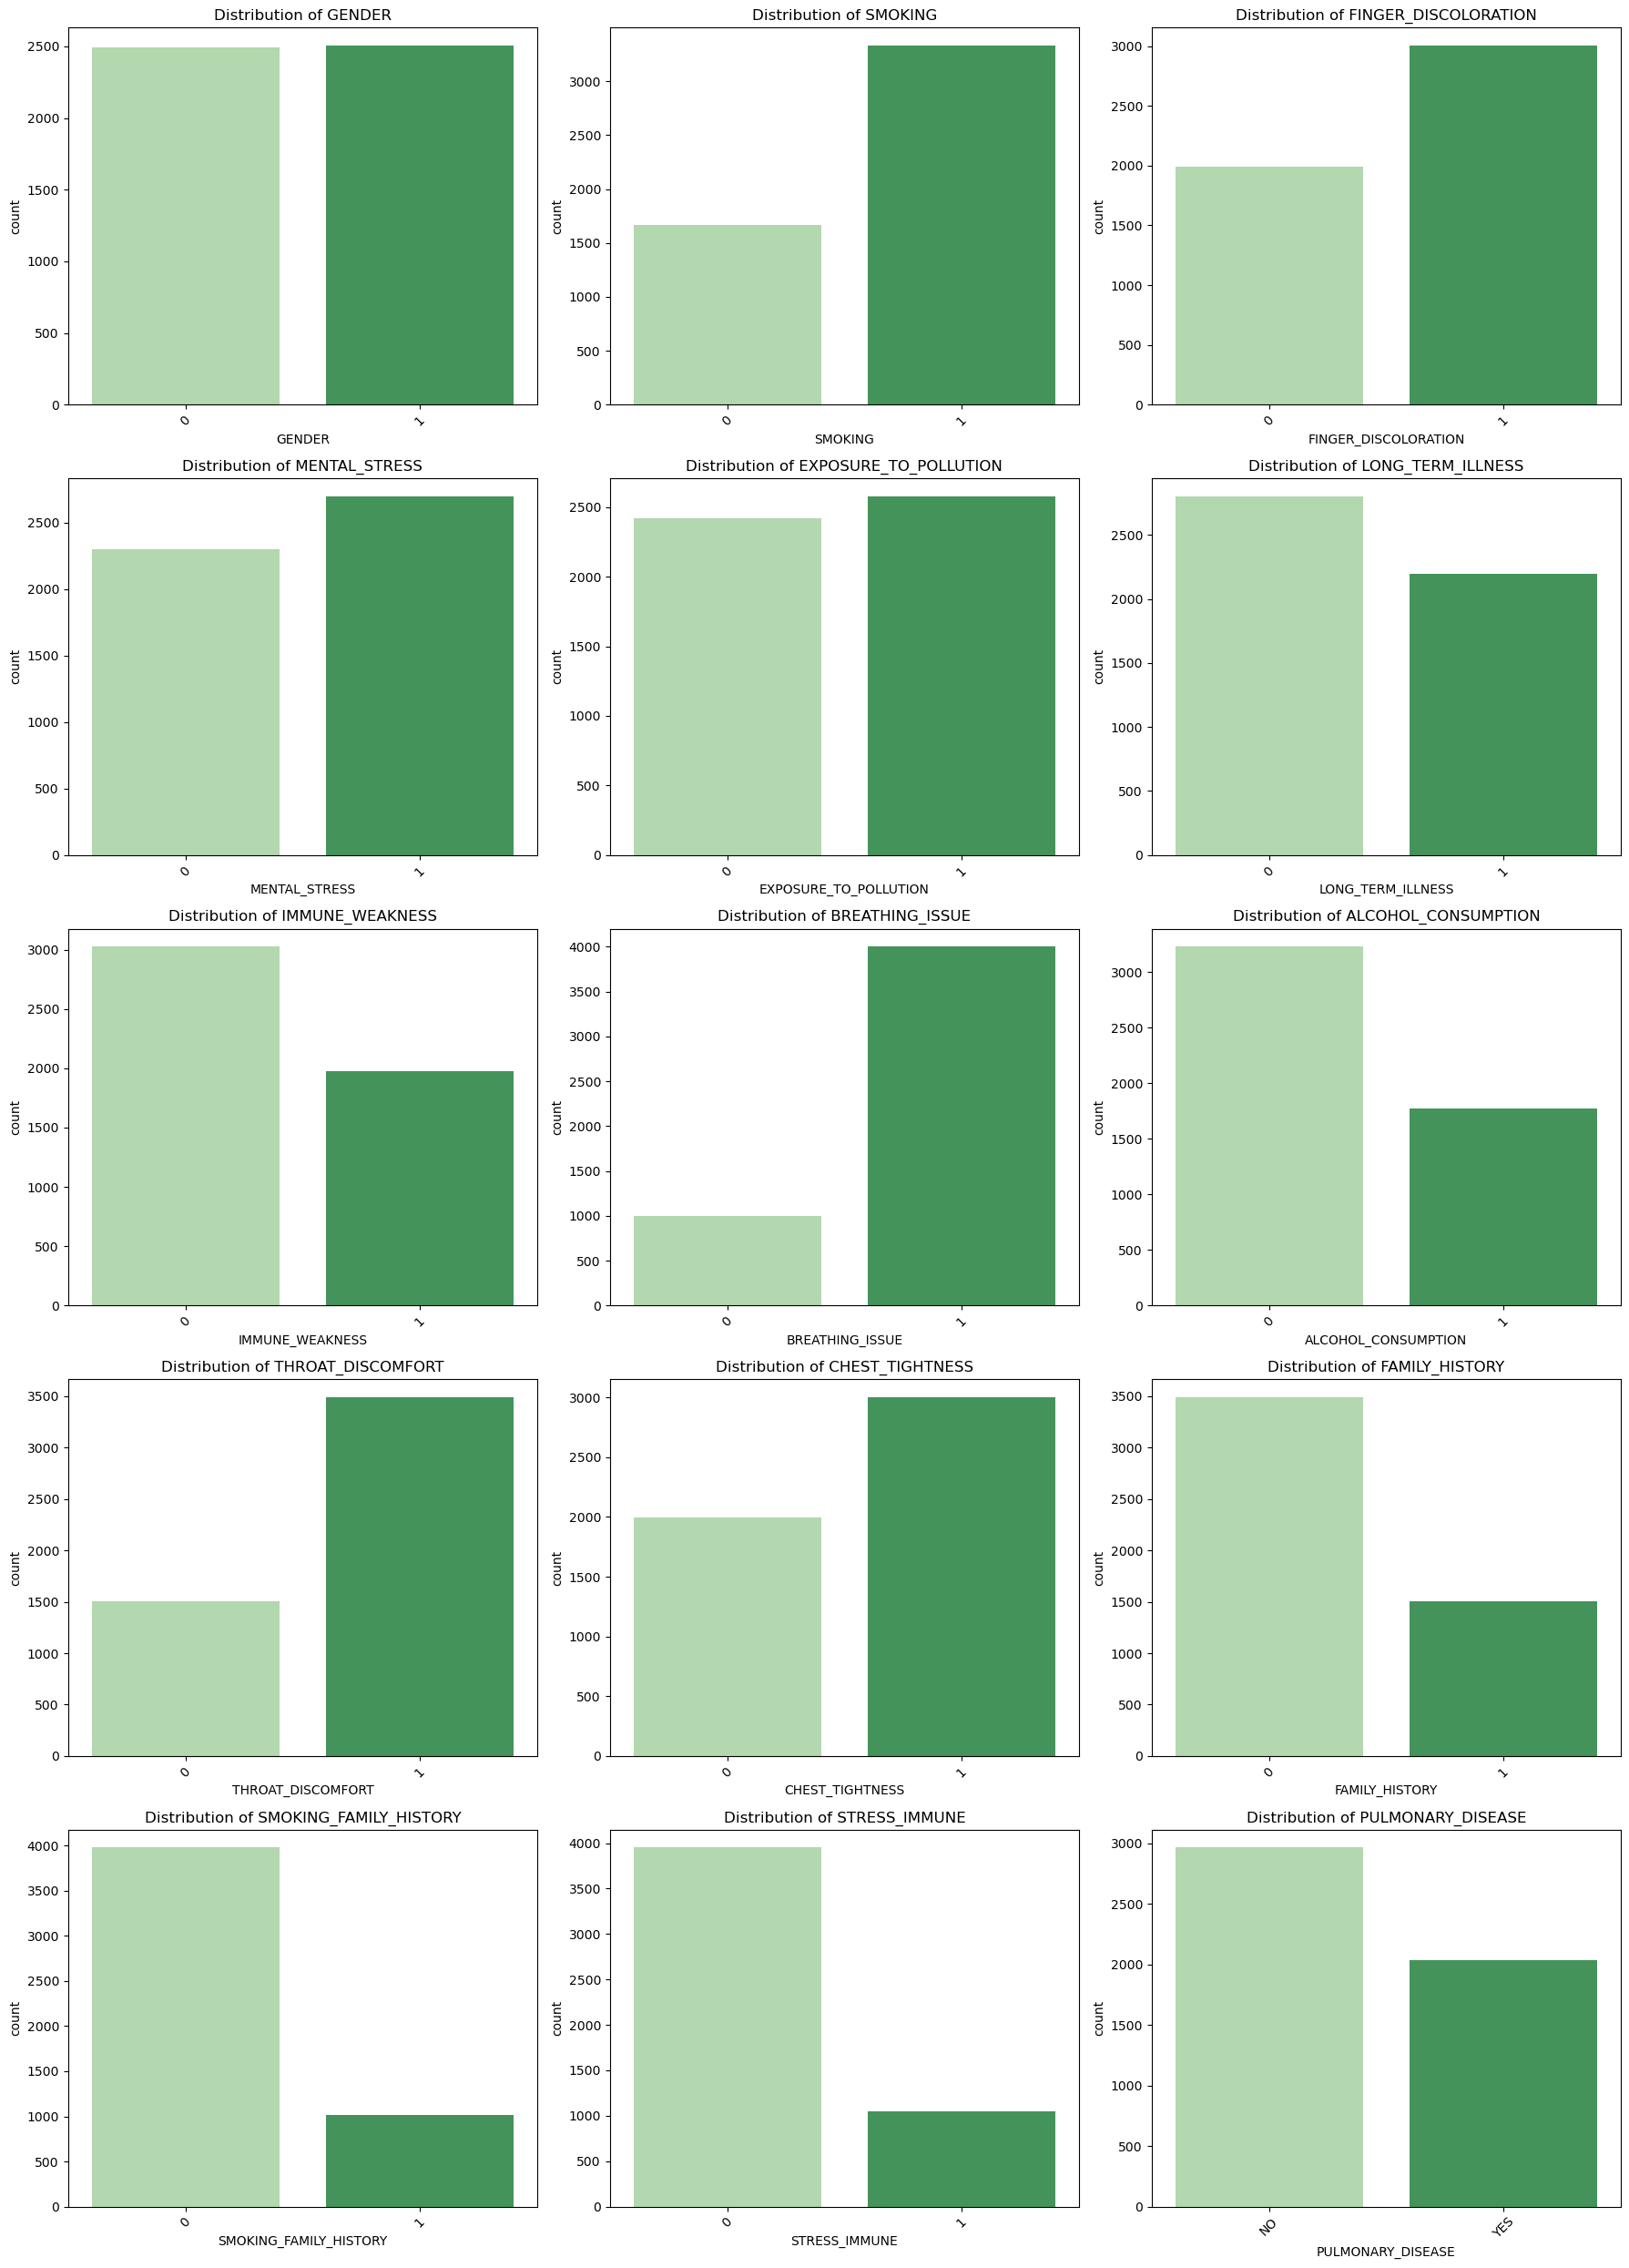

In [32]:
# Set categorical columns
categorical_columns = [col for col in df.columns if df[col].dtype == 'category' or df[col].nunique() <= 10]


# Set up a grid: 3 columns per row
num_plots = len(categorical_columns)
cols = 3
rows = (num_plots // cols) + int(num_plots % cols != 0)

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=df, x=col, hue=col, legend=False, palette='Greens')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

## INTEPRETATION

# 1. Continuous Variables (Pair Plot)
Variables: AGE, ENERGY_LEVEL, OXYGEN_SATURATION

AGE: The distribution of age (top-left) looks fairly uniform with a slight bump in the 70–80 age range. This suggests our dataset includes people across a wide age range, slightly skewed towards older individuals.

ENERGY: The distribution appears to follow a normal curve centered around 60 which indicates that most people report moderate energy levels.

OXYGEN_SATURATION: This is also roughly normally distributed, centered around 95–96% and indicates most individuals are in healthy oxygen ranges, with few outliers.

PAIRWISE RELATIONSHIP INDICATES THERE ARE NO STRONG VISIBLE CORRELATIONS BETWEEN AGE, ENERGY, AND OXYGEN - DATA LOOKS SCATTERED.

# 2. Categorical Variables (Count Plots)
Variables include GENDER, SMOKING, FINGER_DISCOLORATION, etc.

FEATURE AND INTERPRETATION

- GENDER: Fairly balanced distribution between male and female.
- SMOKING: There's higher number of smokers than non-smokers.
- FINGER_DISCOLORATION: More people show discoloration — could be linked with smoking.
- MENTAL_STRESS, EXPOSURE_TO_POLLUTION, LONG_TERM_ILLNESS all show a higher 'Yes' count, implying these are common risk factors.
- IMMUNE_WEAKNESS is less common, more people marked 'No'.
- BREATHING_ISSUE: Majority report breathing issues which is critical symptom for lung problems.
- ALCOHOL_CONSUMPTION: Higher 'No' responses, but a decent number consume alcohol.
- THROAT_DISCOMFORT, CHEST_TIGHTNESS: More people say 'Yes', suggesting they’re common complaints.
- FAMILY_HISTORY, SMOKING_FAMILY_HISTORY: Most do not have family history
- STRESS_IMMUNE:	Very few people are stress-immune, suggesting mental stress could be a key variable.
- PULMONARY_DISEASE: Majority do not have a diagnosed condition yet — this may be a target variable.
  
Overall Insights: Many of the risk factor variables (SMOKING, POLLUTION, STRESS, BREATHING_ISSUE) show positive/Yes as the dominant category, suggesting these may be key drivers of lung issues in the dataset.